# Looping Graph — Higher / Lower Guessing Game

Three nodes: `setup` → `guess` → `hint` with a conditional loop back to `guess` if incorrect.

In [1]:
from typing import TypedDict, Literal
import random

from langgraph.graph import StateGraph, START, END
from IPython.display import display, Markdown, Image

In [2]:
class GameState(TypedDict):
    player_name: str
    target: int
    lower_bound: int
    upper_bound: int
    guess: int
    guesses: list[int]
    hint: str
    attempts: int

In [3]:
def setup(state: GameState) -> GameState:
    return {
        "player_name": state.get("player_name", "Student"),
        "target": random.randint(1, 20),
        "lower_bound": state.get("lower_bound", 1),
        "upper_bound": state.get("upper_bound", 20),
        "guesses": [],
        "attempts": 0,
        "hint": "",
    }


def guess(state: GameState) -> GameState:
    lower = state["lower_bound"]
    upper = state["upper_bound"]
    if state["hint"] == "higher":
        lower = state["guess"] + 1
    elif state["hint"] == "lower":
        upper = state["guess"] - 1
    mid = (lower + upper) // 2
    return {
        "guess": mid,
        "guesses": state["guesses"] + [mid],
        "lower_bound": lower,
        "upper_bound": upper,
        "attempts": state["attempts"] + 1,
    }


def hint(state: GameState) -> GameState:
    g, t = state["guess"], state["target"]
    return {"hint": "correct" if g == t else ("higher" if g < t else "lower")}

In [4]:
def decide_next(state: GameState) -> Literal["continue", "end"]:
    if state["hint"] == "correct" or state["attempts"] >= 7:
        return "end"
    return "continue"

In [5]:
graph = StateGraph(GameState)
graph.add_node("setup", setup)
graph.add_node("guess", guess)
graph.add_node("hint", hint)

graph.add_edge(START, "setup")
graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint")
graph.add_conditional_edges("hint", decide_next, {"continue": "guess", "end": END})

app = graph.compile()

In [6]:
display(Markdown(f"```mermaid\n{app.get_graph().draw_mermaid()}\n```"))

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	setup(setup)
	guess(guess)
	hint(hint)
	__end__([<p>__end__</p>]):::last
	__start__ --> setup;
	guess --> hint;
	hint -. &nbsp;end&nbsp; .-> __end__;
	hint -. &nbsp;continue&nbsp; .-> guess;
	setup --> guess;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

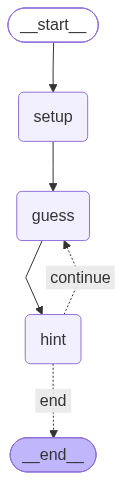

In [7]:
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [8]:
input_state = {"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 20}

print(f"Welcome, {input_state['player_name']}! The game has begun. I'm thinking of a number between 1 and 20.")

target = None
for chunk in app.stream(input_state):
    for node, vals in chunk.items():
        if node == "setup":
            target = vals.get("target", target)
        elif node == "guess":
            attempt = vals["attempts"]
            g = vals["guess"]
            lo, hi = vals["lower_bound"], vals["upper_bound"]
            print(f"Attempt {attempt}: Guessing {g} (Current range: {lo}-{hi})")
        elif node == "hint":
            h = vals["hint"]
            if h == "correct":
                print(f"Success! Correct! You found the number {target} in {attempt} attempts.")
                print("GAME OVER: Number found!")
            elif h == "higher":
                print(f"Hint: The number {g} is too low. Try higher!")
                print(f"CONTINUING: {attempt}/7 attempts used")
            else:
                print(f"Hint: The number {g} is too high. Try lower!")
                print(f"CONTINUING: {attempt}/7 attempts used")

Welcome, Student! The game has begun. I'm thinking of a number between 1 and 20.
Attempt 1: Guessing 10 (Current range: 1-20)
Hint: The number 10 is too low. Try higher!
CONTINUING: 1/7 attempts used
Attempt 2: Guessing 15 (Current range: 11-20)
Success! Correct! You found the number 15 in 2 attempts.
GAME OVER: Number found!


In [9]:
for i in range(3):
    print("=" * 50)
    input_state = {"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 20}
    print(f"Welcome, {input_state['player_name']}! The game has begun. I'm thinking of a number between 1 and 20.")
    target = None
    for chunk in app.stream(input_state):
        for node, vals in chunk.items():
            if node == "setup":
                target = vals.get("target", target)
            elif node == "guess":
                attempt = vals["attempts"]
                g = vals["guess"]
                lo, hi = vals["lower_bound"], vals["upper_bound"]
                print(f"Attempt {attempt}: Guessing {g} (Current range: {lo}-{hi})")
            elif node == "hint":
                h = vals["hint"]
                if h == "correct":
                    print(f"Success! Correct! You found the number {target} in {attempt} attempts.")
                    print("GAME OVER: Number found!")
                elif h == "higher":
                    print(f"Hint: The number {g} is too low. Try higher!")
                    print(f"CONTINUING: {attempt}/7 attempts used")
                else:
                    print(f"Hint: The number {g} is too high. Try lower!")
                    print(f"CONTINUING: {attempt}/7 attempts used")

Welcome, Student! The game has begun. I'm thinking of a number between 1 and 20.
Attempt 1: Guessing 10 (Current range: 1-20)
Hint: The number 10 is too low. Try higher!
CONTINUING: 1/7 attempts used
Attempt 2: Guessing 15 (Current range: 11-20)
Hint: The number 15 is too low. Try higher!
CONTINUING: 2/7 attempts used
Attempt 3: Guessing 18 (Current range: 16-20)
Hint: The number 18 is too high. Try lower!
CONTINUING: 3/7 attempts used
Attempt 4: Guessing 16 (Current range: 16-17)
Hint: The number 16 is too low. Try higher!
CONTINUING: 4/7 attempts used
Attempt 5: Guessing 17 (Current range: 17-17)
Success! Correct! You found the number 17 in 5 attempts.
GAME OVER: Number found!
Welcome, Student! The game has begun. I'm thinking of a number between 1 and 20.
Attempt 1: Guessing 10 (Current range: 1-20)
Hint: The number 10 is too high. Try lower!
CONTINUING: 1/7 attempts used
Attempt 2: Guessing 5 (Current range: 1-9)
Hint: The number 5 is too low. Try higher!
CONTINUING: 2/7 attempts u